# Analyse NextBuy — Simon
## Objectif : identifier les best sellers et les profils d'achat healthy

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
print("Chargement des données...")
aisles = pd.read_csv('./datasets/aisles.csv')
departments = pd.read_csv('./datasets/departments.csv')
products = pd.read_csv('./datasets/products.csv')
orders = pd.read_csv('./datasets/orders.csv', nrows=100_000)
order_products = pd.read_csv('./datasets/order_products.csv', nrows=100_000) 

print("Fusion en cours...")
products_enriched = products.merge(aisles, on='aisle_id', how='left')
products_enriched = products_enriched.merge(departments, on='department_id', how='left')

orders_details = order_products.merge(orders, on='order_id', how='left')

df_master = orders_details.merge(products_enriched, on='product_id', how='left')

print("Fusion terminée !")
display(df_master.head())
print(f"Dimensions du dataset final : {df_master.shape}")

Chargement des données...
Fusion en cours...
Fusion terminée !


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,Organic Egg Whites,86.0,16.0,eggs,dairy eggs
1,2,28985.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,Michigan Organic Kale,83.0,4.0,fresh vegetables,produce
2,2,9327.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,Garlic Powder,104.0,13.0,spices seasonings,pantry
3,2,45918.0,4.0,1.0,NaN,NaN,NaN,NaN,NaN,Coconut Butter,19.0,13.0,oils vinegars,pantry
4,2,30035.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,Natural Sweetener,17.0,13.0,baking ingredients,pantry


Dimensions du dataset final : (100000, 14)


In [13]:
print("Nombre de Valeurs nul dans le Dataset",df_master.isnull())
print("<=======================>")
print("Nombre de NaN dans chaque column:", df_master.isnull().sum())


Nombre de Valeurs nul dans le Dataset        order_id  product_id  add_to_cart_order  reordered  user_id  \
0         False       False              False      False     True   
1         False       False              False      False     True   
2         False       False              False      False     True   
3         False       False              False      False     True   
4         False       False              False      False     True   
...         ...         ...                ...        ...      ...   
99995     False       False              False      False     True   
99996     False       False              False      False     True   
99997     False       False              False      False     True   
99998     False       False              False      False     True   
99999     False       False              False      False     True   

       order_number  order_dow  order_hour_of_day  days_since_prior_order  \
0              True       True              

## 

## EASY	Find the best seller per  departement 

#### je dois d'abord trouver les product_id qui sont le plus commandés

In [14]:
ID_Product_Greater = df_master['product_id'].value_counts(dropna=False)
print(ID_Product_Greater)



product_id
24852.0    1459
13176.0    1216
21137.0     814
21903.0     719
47209.0     647
           ... 
30435.0       1
14873.0       1
13332.0       1
21205.0       1
45096.0       1
Name: count, Length: 16416, dtype: int64


### et les traduire avec leurs noms de produit et trouver la correlation  

In [15]:
dfProductaffilate= (df_master[["product_id", "product_name"]].head())
display(dfProductaffilate)

,product_id,product_name
0,33120.0,Organic Egg Whites
1,28985.0,Michigan Organic Kale
2,9327.0,Garlic Powder
3,45918.0,Coconut Butter
4,30035.0,Natural Sweetener


### On tchek le nombre d'achat, dans le tableau qu'on crée

In [16]:

ventes =(df_master.groupby(["department_id", "department", "product_id", "product_name"], as_index=False).size().rename(columns={"size": "nombres_Dachat"}))
ventes.head()

,department_id,department,product_id,product_name,nombres_Dachat
0,1.0,frozen,4.0,Smart Ones Classic Favorites Mini Rigatoni Wit...,1
1,1.0,frozen,12.0,Chocolate Fudge Layer Cake,1
2,1.0,frozen,30.0,"Three Cheese Ziti, Marinara with Meatballs",1
3,1.0,frozen,46.0,Raisin Cinnamon Bagels 5 count,2
4,1.0,frozen,100.0,Peanut Butter & Strawberry Jam Sandwich,1


In [17]:
df = pd.DataFrame(df_master)
df = df.set_index("department")
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle
department,,,,,,,,,,,,,
dairy eggs,2,33120.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,Organic Egg Whites,86.0,16.0,eggs
produce,2,28985.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,Michigan Organic Kale,83.0,4.0,fresh vegetables
pantry,2,9327.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,Garlic Powder,104.0,13.0,spices seasonings
pantry,2,45918.0,4.0,1.0,NaN,NaN,NaN,NaN,NaN,Coconut Butter,19.0,13.0,oils vinegars
pantry,2,30035.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,Natural Sweetener,17.0,13.0,baking ingredients


### 

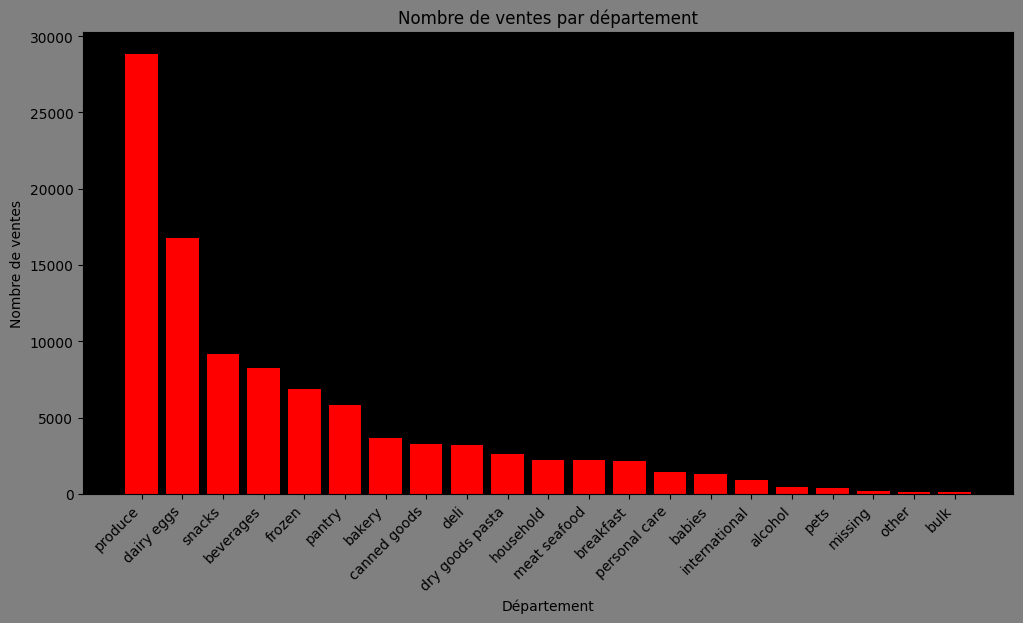

In [18]:
import matplotlib.pyplot as plt

# Compter le nombre de ventes par département
ventes_par_dept = df_master.groupby('department').size().sort_values(ascending=False)



plt.figure(figsize=(12, 6),facecolor='grey')
ax = plt.gca()  
ax.set_facecolor("black")
plt.bar(ventes_par_dept.index, ventes_par_dept.values, color='red')
plt.title('Nombre de ventes par département')
plt.xlabel('Département')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.show()

## Meilleur visualisation sur un Camembert

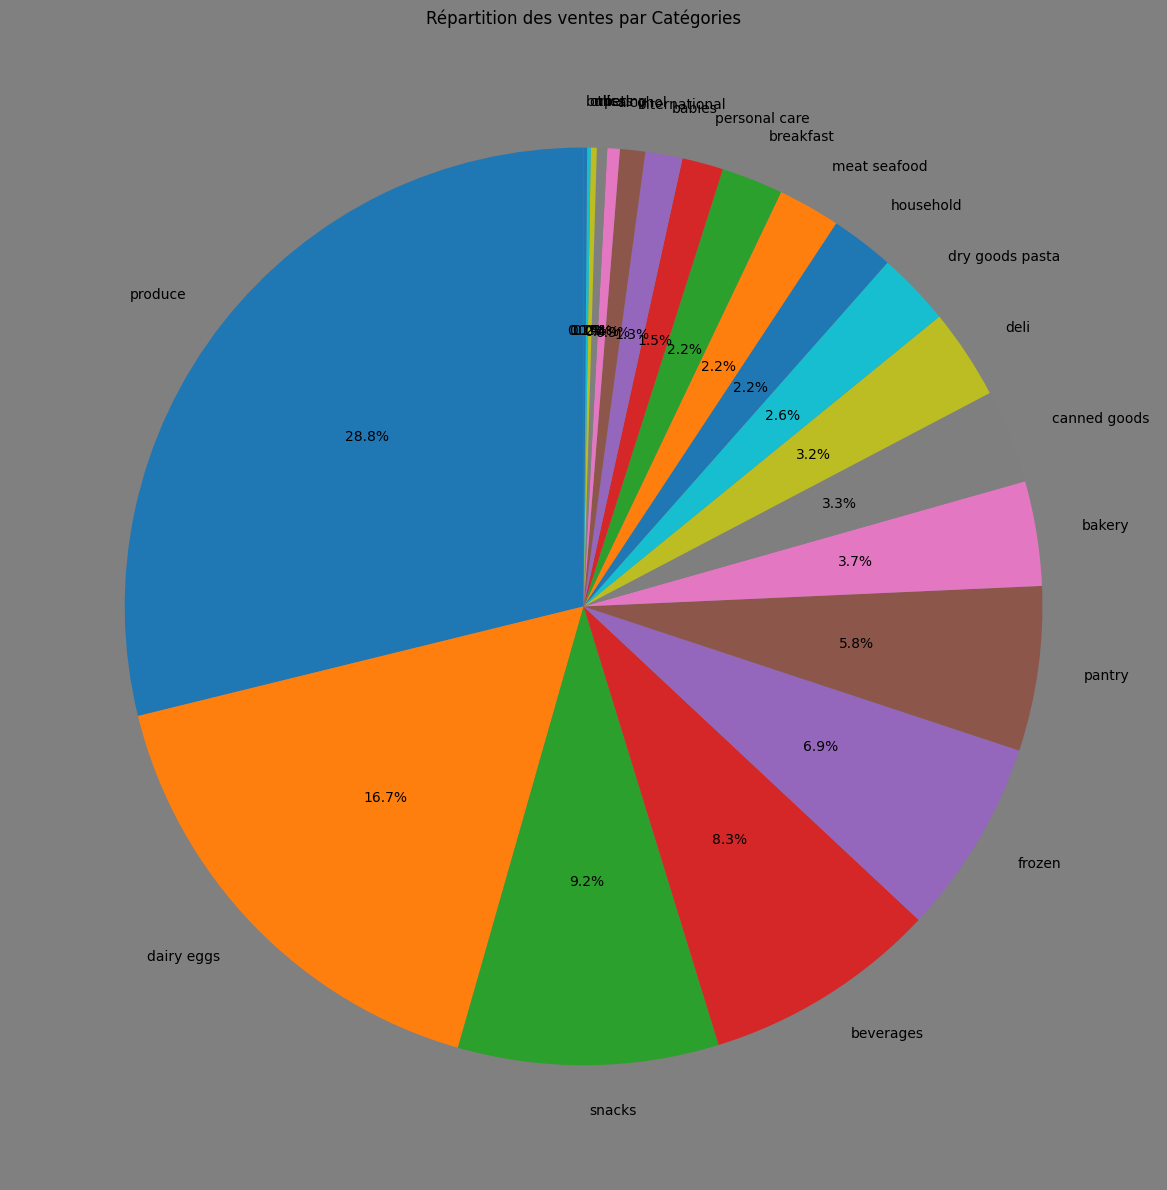

In [19]:

plt.figure(figsize=(12, 12),facecolor='grey')
plt.pie(
    ventes_par_dept.values,
    labels=ventes_par_dept.index,
    autopct='%1.1f%%',     
    startangle=90,           
)

plt.title('Répartition des ventes par Catégories')
plt.tight_layout()
plt.show()

### La data "Produce" est très grande car c'est les fruit et legumes , c'est donc des produits pérrisable et donc a haut rendement 


# HARD , Trouver les produits healthy , bon pour le corps , protéiné , low calories qui pourraient êtres recommendé pour les Client qui cherchent à perdre du Poids.
### Donc afficher un graphique qui donnerai le pourcentage de produit healthy par departement 

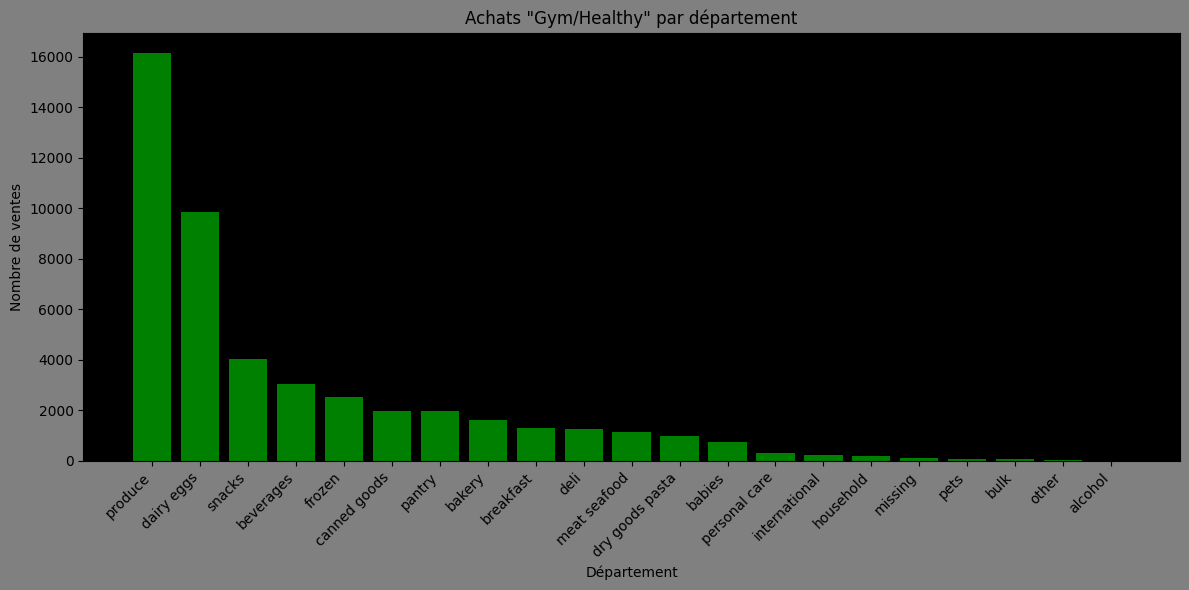

In [24]:
keywords_healthy = [
    # Protéines
    'protein', 'whey', 'casein', 'collagen', 'egg white', 'tuna', 
    'chicken breast', 'turkey', 'tofu', 'tempeh', 'edamame',

    # Healthy / Clean eating
    'organic', 'natural', 'whole grain', 'multigrain', 'whole wheat',
    'sugar free', 'sugar-free', 'fat free', 'fat-free', 'low fat',
    'low-fat', 'low calorie', 'low carb', 'low sodium', 'light',
    'reduced', 'zero', 'no added sugar', 'unsweetened',

    # Superfoods / Fitness
    'kale', 'spinach', 'quinoa', 'chia', 'flax', 'hemp',
    'acai', 'spirulina', 'matcha', 'turmeric', 'ginger',
    'almond', 'cashew', 'walnut', 'oat', 'granola',

    # Régimes
    'vegan', 'gluten free', 'gluten-free', 'dairy free', 'dairy-free',
    'paleo', 'keto', 'non-gmo', 'non gmo',

    # Boissons sport
    'electrolyte', 'energy', 'bcaa', 'creatine', 'pre-workout',
    'coconut water', 'green tea', 'kombucha',

    # Laitage healthy
    'greek yogurt', 'skyr', 'cottage', 'almond milk', 'oat milk',
    'soy milk', 'plant based', 'plant-based'
]
pattern_healthy = '|'.join(keywords_healthy)                    
healthy_df = df_master[df_master['product_name'].str.lower().str.contains(pattern_healthy, na=False)]

# Compter les ventes de ces produits par category(departement)
ventes_gym = healthy_df.groupby('department').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6),facecolor='grey')
ax = plt.gca()  
ax.set_facecolor("black")
plt.bar(ventes_gym.index, ventes_gym.values, color='green')
plt.title('Achats "Gym/Healthy" par département')
plt.xlabel('Département')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## On retrouve la même statistique que le graph de nombre de vente pas departement car c'est evidement coorélée.
### je vais essayer de creuser un peu plus et diviser la range dfe filtre

# Start of Useless stats


# Produit Protéiné par Catégories

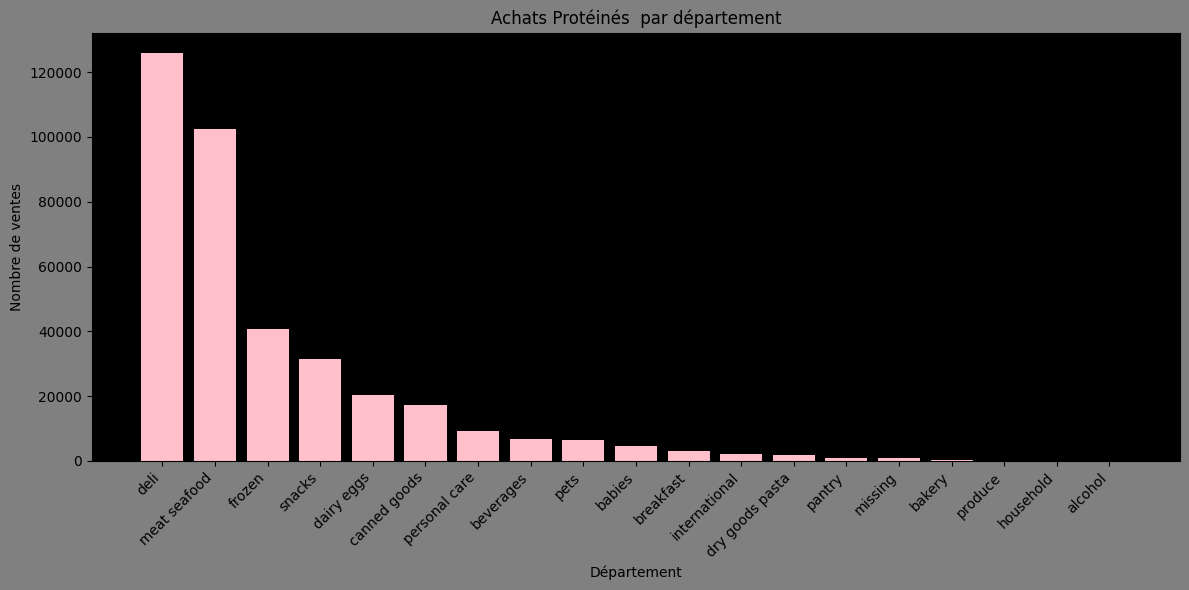

In [ ]:
keywords = [
    # Protéines
    'protein', 'whey', 'casein', 'collagen', 'egg white', 'tuna', 
    'chicken breast', 'turkey', 'tofu', 'tempeh', 'edamame']
pattern = '|'.join(keywords) 

gym_df = df_master[df_master['product_name'].str.lower().str.contains(pattern, na=False)]

# Compter les ventes de ces produits par category(departement)
ventes_gym = gym_df.groupby('department').size().sort_values(ascending=False)
plt.figure(figsize=(12, 6),facecolor='grey')
ax = plt.gca()  
ax.set_facecolor("black")

plt.bar(ventes_gym.index, ventes_gym.values, color='pink')
plt.title('Achats Protéinés  par département')
plt.xlabel('Département')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### "Deli" veut dire "Delicatessen food" donc en gros de la nourriture de haute qualité , avec des produits Etiquement correcte a base de viandes donc protéiné qui sont déjà cuisiné et prêt à manger d'où la première place. 

# Produuit healthy ou clean par departement 

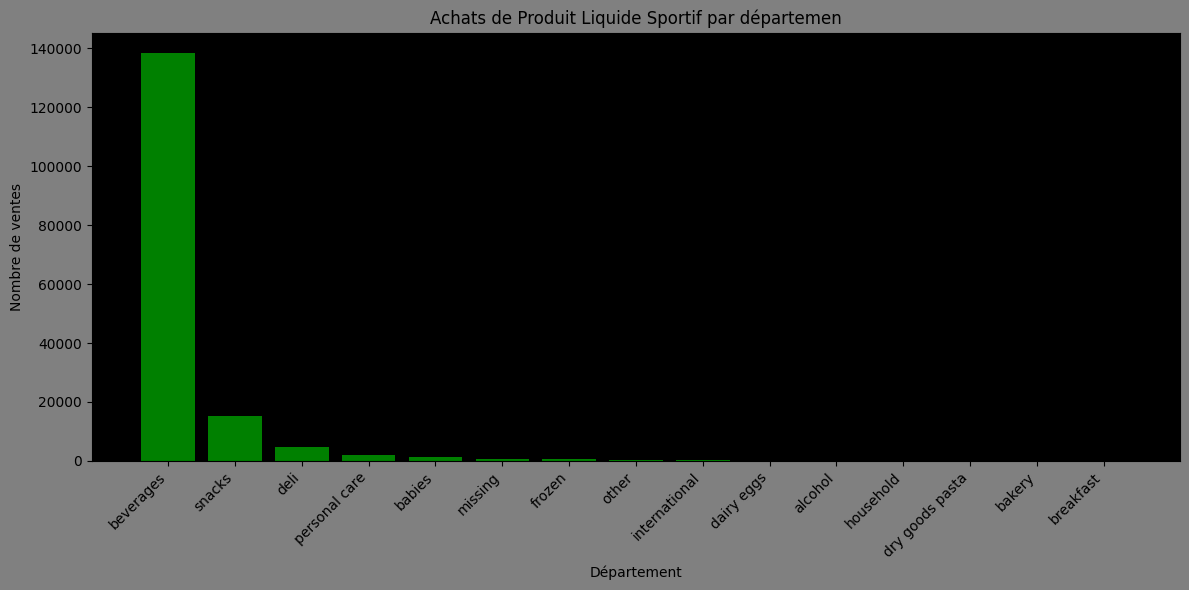

In [ ]:
keywords = [
    'electrolyte', 'energy', 'bcaa', 'creatine', 'pre-workout',
    'coconut water', 'green tea', 'kombucha']
pattern = '|'.join(keywords) 

gym_df = df_master[df_master['product_name'].str.lower().str.contains(pattern, na=False)]

# Compter les ventes de ces produits par category(departement)
ventes_gym = gym_df.groupby('department').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6),facecolor='grey')
ax = plt.gca()  
ax.set_facecolor("black")
plt.bar(ventes_gym.index, ventes_gym.values, color='green')
plt.title('Achats de Produit Liquide Sportif par départemen')
plt.xlabel('Département')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Donc c'est logique que les Fruits et Legumes soient en premiers 

## Laitage healthy

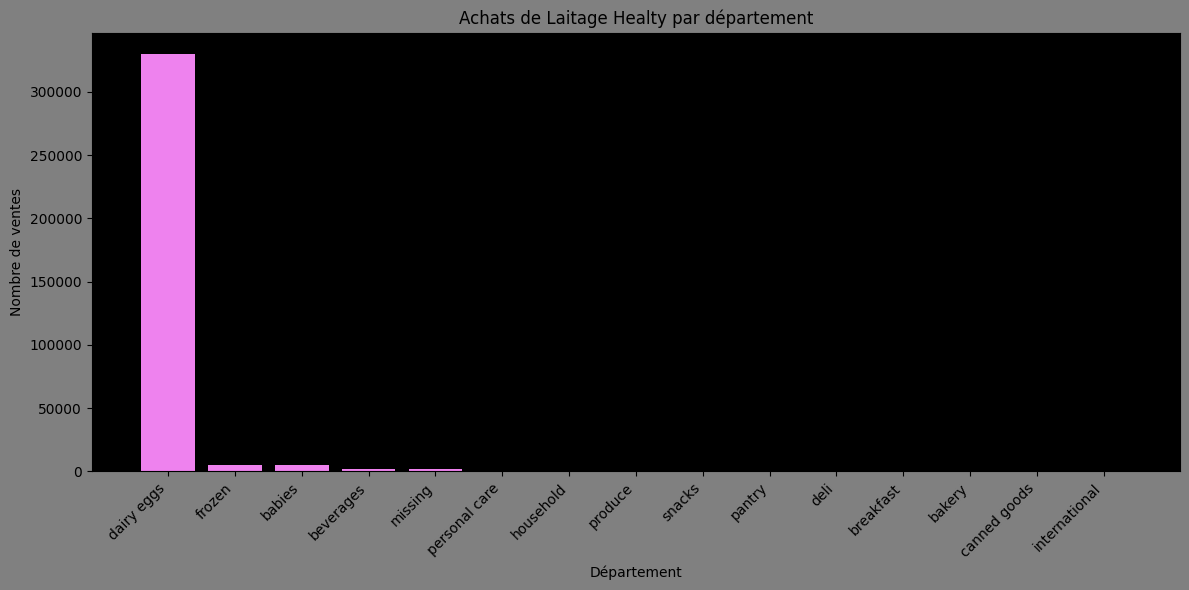

In [ ]:
keywords = [
    'greek yogurt', 'skyr', 'cottage', 'almond milk', 'oat milk',
    'soy milk', 'plant based', 'plant-based']
pattern = '|'.join(keywords) 

gym_df = df_master[df_master['product_name'].str.lower().str.contains(pattern, na=False)]

# Compter les ventes de ces produits par category(departement)
ventes_gym = gym_df.groupby('department').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6),facecolor='grey')
ax = plt.gca()  
ax.set_facecolor("black")
plt.bar(ventes_gym.index, ventes_gym.values, color='violet')
plt.title('Achats de Laitage Healthy par département')
plt.xlabel('Département')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# End of Useless stats

# Quel % des achats totaux sont healthy ? 

### Je vais d'abord filtrer et cibler les produits non healthy avant de les comparées avec les produits healthy 

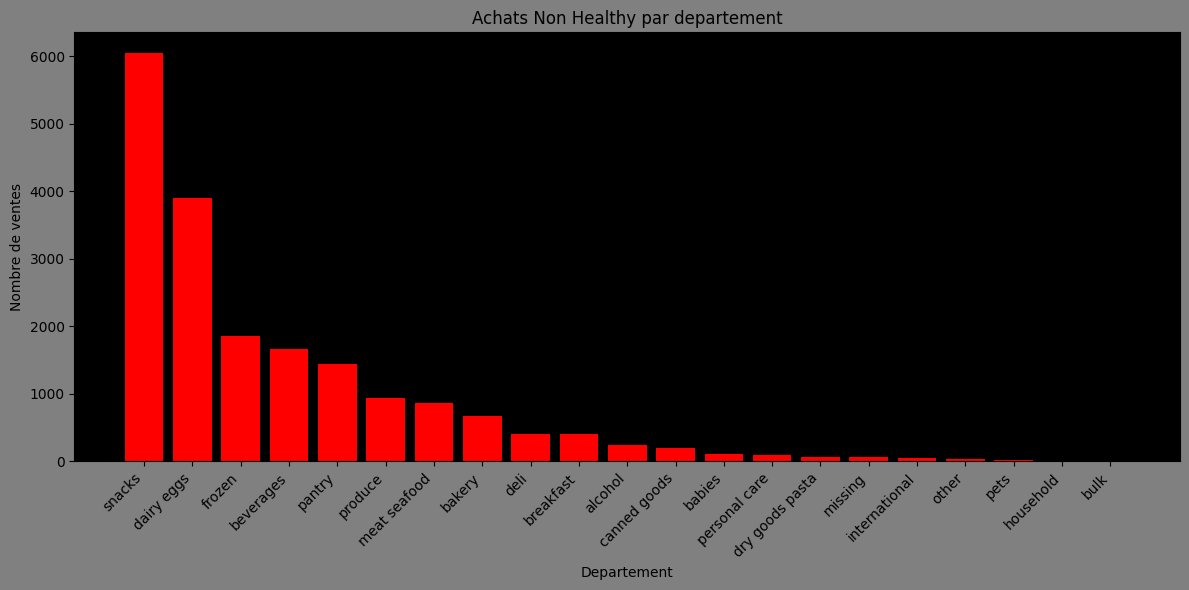

In [25]:
unhealthy_keywords = [

    'chips', 'crackers', 'popcorn', 'pretzel', 'nachos',
    'hot dog', 'bacon', 'sausage', 'pepperoni', 'salami',

    
    'candy', 'chocolate', 'cookie', 'brownie', 'cake',
    'donut', 'muffin', 'waffle', 'pancake', 'syrup',
    'frosting', 'fudge', 'caramel', 'marshmallow', 'gummy',
    'lollipop', 'licorice', 'toffee', 'nougat',

 
    'soda', 'cola', 'sprite', 'fanta', 'energy drink',
    'juice drink', 'lemonade', 'sweetened', 'flavored drink',


    'cream cheese', 'heavy cream', 'whipped cream', 'butter',
    'full fat', 'whole milk', 'mayo', 'mayonnaise',

 
    'fried', 'deep fried', 'crispy', 'crunchy snack',
    'instant', 'processed', 'frozen pizza', 'mac and cheese',


    'beer', 'wine', 'vodka', 'whiskey', 'rum', 'tequila',
    'ale', 'lager', 'cider', 'cocktail', 'hard seltzer',

    'salted', 'extra salt', 'pickled', 'jerky',
]

pattern_unhealthy = '|'.join(unhealthy_keywords)         
unhealthy_df = df_master[df_master['product_name'].str.lower().str.contains(pattern, na=False)]  

ventes_unhealthy = unhealthy_df.groupby('department').size().sort_values(ascending=False)  

plt.figure(figsize=(12, 6), facecolor='grey')
ax = plt.gca()
ax.set_facecolor("black")
plt.bar(ventes_unhealthy.index, ventes_unhealthy.values, color='red')
plt.title('Achats Non Healthy par departement')
plt.xlabel('Departement')
plt.ylabel('Nombre de ventes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Nous retrouvons bien les snack en première Place

# Produit Healthy vs Produit Non-Healthy

# Pour comparer les deux 

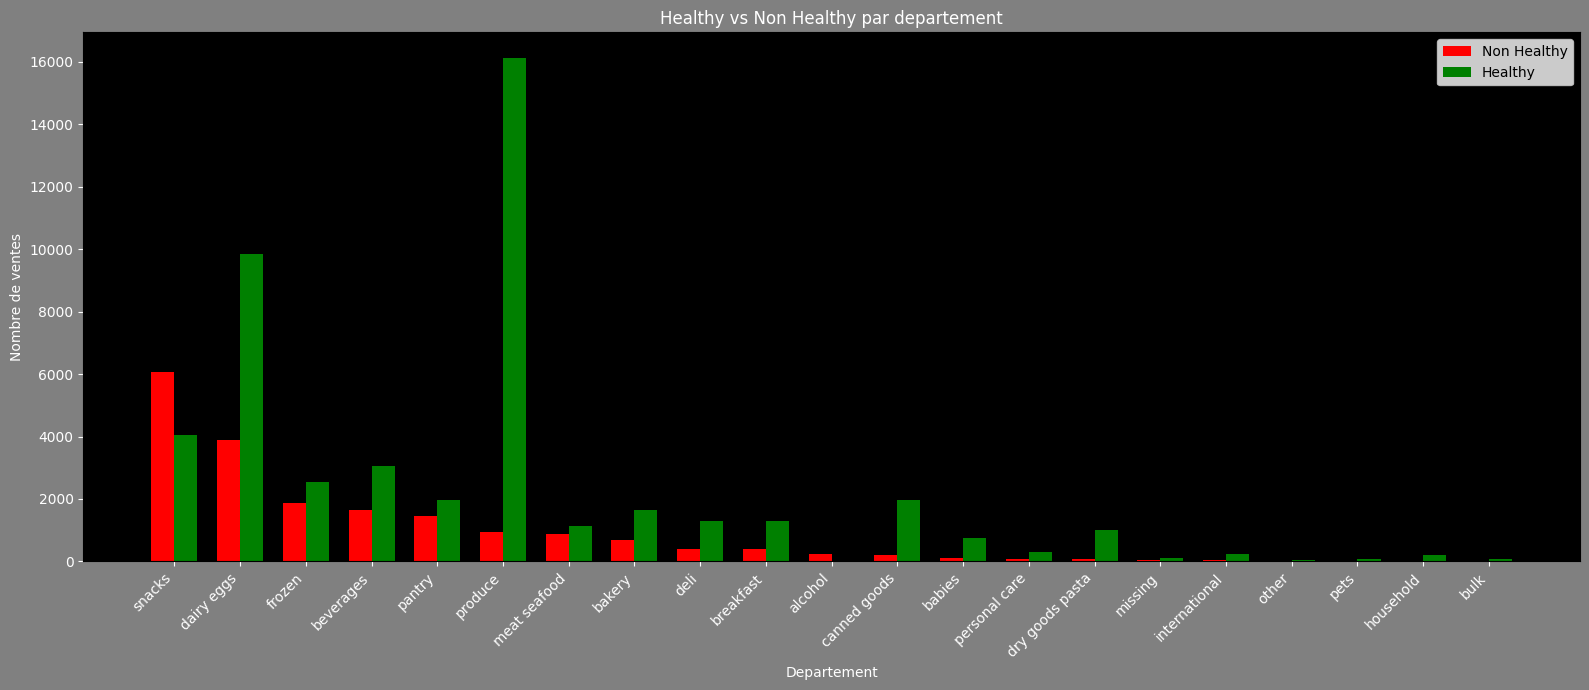

In [ ]:
import numpy as np

ventes_healthy = healthy_df.groupby('department').size()
ventes_unhealthy = unhealthy_df.groupby('department').size()
#reindex force les deux a avoir le meme departement dans le meme ordre pour qu'ils sooient tous a coté de leurs homonyme  
all_depts = ventes_unhealthy.sort_values(ascending=False).index 
healthy_aligned = ventes_healthy.reindex(all_depts, fill_value=0)
unhealthy_aligned = ventes_unhealthy.reindex(all_depts, fill_value=0)
#remplace les noms des departemetn par des chiffres sinon on aurait pas pu les mettre, 
x = np.arange(len(all_depts))
width = 0.35

plt.figure(figsize=(16, 7), facecolor='grey')
ax = plt.gca()
ax.set_facecolor('black')
#placements des bar espacer pour pas qu'ils se chevauchent 
plt.bar(x - width/2, unhealthy_aligned.values, width=width, color='red', label='Non Healthy')
plt.bar(x + width/2, healthy_aligned.values, width=width, color='green', label='Healthy')

plt.xticks(x, all_depts, rotation=45, ha='right', color='white')#xticks remet les noms des departemetns sur l axe X a la fin 
plt.title('Healthy vs Non Healthy par departement', color='white')
plt.xlabel('Departement', color='white')
plt.ylabel('Nombre de ventes', color='white')
plt.tick_params(colors='white')
plt.legend()
plt.tight_layout()
plt.show()

### on remarque donc que les clients sont donc assez Healthy et responsable , ce ne sont suremment pas des Américains 